# Imports

In [75]:
import matplotlib.pyplot as plt
import numpy as np

### Import Prerequis

In [76]:
import sys
import os
import subprocess

sys.path.append(os.path.abspath(os.path.join('..')))

### Compile Library C and generate JSON (make)

In [77]:
try:
    result = subprocess.run(
        "make -C ../libc clean && make -C ../libc",
        shell=True,
        capture_output=True,
        text=True
    )
    # print(result.stdout)

    if result.stderr:
        print(result.stderr)
    
    if result.returncode != 0:
        print(f"Build failed with exit code {result.returncode}")
        sys.exit(1)
    else:
        print("Build succeeded.")

except Exception as e:
    print(f"Build failed: {e}")
    sys.exit(1)

Build succeeded.


### Import Loader

In [78]:
from engine.interop.loader import Loader

# On doit restart kernel si on veut recharger la lib
try:
    Loader.loadLibrary(
        lib_name="libc",
        lib_folder="../libc",
        build_folder="../libc/build",
        specs_folder="../libc/specs",
        seed=None # ca va generer une seed aleatoire
    )

except Exception as e:
    if "already loaded" not in str(e).lower():
        raise RuntimeError(f"Failed to load library: {e}")
    
    print("Library already loaded, skipping.")

Library already loaded, skipping.


### Linear Model

In [79]:
from engine.interop.linearModel import LinearModel

In [80]:
def _normalize_targets(Y: np.ndarray) -> np.ndarray:
    return Y if Y.ndim == 2 else Y.reshape(-1, 1)


def _encode_targets(Y_matrix: np.ndarray, is_classification: bool) -> np.ndarray:
    if is_classification:
        return Y_matrix.astype(int)
    return Y_matrix.astype(float)


def _train_binary_model(
        X: np.ndarray,
        Y_column: np.ndarray,
        is_classification: bool,
        alpha: float,
        epochs: int
    ) -> LinearModel:
    model = LinearModel.init_random(input_dim=len(X[0]))
    model.train(
        dataset_inputs=X.ravel().tolist(),
        dataset_expected_outputs=Y_column.ravel().tolist(),
        alpha=alpha,
        epochs=epochs,
        is_classification=is_classification
    )
    return model


def _predict_binary_model(model: LinearModel, input_data: list[float], is_classification: bool) -> float | int:
    predicted_output = model.predict(input_data, is_classification=is_classification)
    return float(predicted_output) if not is_classification else int(predicted_output)


def _train_multiclass_models(
        X: np.ndarray,
        Y_train: np.ndarray,
        is_classification: bool,
        alpha: float,
        epochs: int
    ) -> list[LinearModel]:
    models = []
    for class_index in range(Y_train.shape[1]):
        model = _train_binary_model(
            X=X,
            Y_column=Y_train[:, class_index],
            is_classification=is_classification,
            alpha=alpha,
            epochs=epochs
        )
        models.append(model)
    return models


def _predict_multiclass_models(models: list[LinearModel], input_data: list[float]) -> np.ndarray:
    return np.array([
        int(model.predict(input_data, is_classification=True))
        for model in models
    ])


def test_linear_model(
        X: np.ndarray,
        Y: np.ndarray,
        is_classification: bool,
        alpha: float = 0.05,
        epochs: int = 80
    ) -> np.ndarray:
    
    Y_matrix = _normalize_targets(Y)
    Y_train = _encode_targets(Y_matrix, is_classification)
    
    if Y_train.shape[1] == 1:
        models = [_train_binary_model(X, Y_train[:, 0], is_classification, alpha, epochs)]
    else:
        models = _train_multiclass_models(X, Y_train, is_classification, alpha, epochs)
    
    total = len(X)
    correct = 0
    incorrect_cases = []
    predictions = []
    
    for i in range(total):
        input_data = X[i].tolist()
        expected_output = Y_matrix[i]
        expected_encoded = Y_train[i]
        
        if len(models) == 1:
            predicted_output = _predict_binary_model(models[0], input_data, is_classification)
            is_correct = predicted_output == expected_encoded.item()
        else:
            predicted_output = _predict_multiclass_models(models, input_data)
            is_correct = np.array_equal(predicted_output, expected_encoded.astype(int))
        
        predictions.append(predicted_output)
        
        if is_correct:
            correct += 1
        else:
            incorrect_cases.append((i, expected_output.tolist(), predicted_output.tolist() if isinstance(predicted_output, np.ndarray) else predicted_output))
    
    print(f"Total cases: {total}")
    print(f"Correct cases: {correct} ({correct/total*100:.2f}%)")
    print(f"Incorrect cases: {len(incorrect_cases)} ({len(incorrect_cases)/total*100:.2f}%)")
    
    if incorrect_cases:
        print("\nFirst incorrect cases (idx, expected, predicted):")
        for row in incorrect_cases[:10]:
            print(row)
    
    return np.array(predictions)

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [81]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
     -1,
     -1
])

# tout mettre sur une ligne (avec bon type)

X_input = X.ravel()
Y_input = Y.ravel().astype(int).ravel()

In [82]:
print("#=== Linear Model ===#\n")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)
print("\n#=== Linear Model ===#")

#=== Linear Model ===#

Total cases: 3
Correct cases: 3 (100.00%)
Incorrect cases: 0 (0.00%)

#=== Linear Model ===#


In [83]:
# plt.scatter(X[0, 0], X[0, 1], color='blue')
# plt.scatter(X[1:3,0], X[1:3,1], color='red')
# plt.show()
# plt.clf()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [84]:
X = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2])
])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

In [85]:
print("#=== Linear Model ===#\n")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)
print("\n#=== Linear Model ===#")

#=== Linear Model ===#

Total cases: 100
Correct cases: 100 (100.00%)
Incorrect cases: 0 (0.00%)

#=== Linear Model ===#


In [86]:
# plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
# plt.scatter(X[50:100,0], X[50:100,1], color='red')
# plt.show()
# plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [87]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

In [88]:
print("#=== Linear Model ===#\n")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)
print("\n#=== Linear Model ===#")

#=== Linear Model ===#

Total cases: 4
Correct cases: 2 (50.00%)
Incorrect cases: 2 (50.00%)

First incorrect cases (idx, expected, predicted):
(0, [1], -1)
(1, [1], -1)

#=== Linear Model ===#


In [89]:
# plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
# plt.scatter(X[2:4,0], X[2:4,1], color='red')
# plt.show()
# plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [90]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

In [91]:
print("#=== Linear Model ===#\n")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)
print("\n#=== Linear Model ===#")

#=== Linear Model ===#

Total cases: 500
Correct cases: 276 (55.20%)
Incorrect cases: 224 (44.80%)

First incorrect cases (idx, expected, predicted):
(0, [-1], 1)
(1, [-1], 1)
(2, [-1], 1)
(3, [-1], 1)
(4, [-1], 1)
(5, [-1], 1)
(7, [-1], 1)
(11, [-1], 1)
(12, [-1], 1)
(13, [-1], 1)

#=== Linear Model ===#


In [92]:
# plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
# plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
# plt.show()
# plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [93]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

In [94]:
print("#=== Linear Model ===#\n")
test_linear_model(X, Y, is_classification=True, alpha=0.05, epochs=800)
print("\n#=== Linear Model ===#")

#=== Linear Model ===#

Total cases: 400
Correct cases: 400 (100.00%)
Incorrect cases: 0 (0.00%)

#=== Linear Model ===#


In [95]:
# plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
# plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
# plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
# plt.show()
# plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [96]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

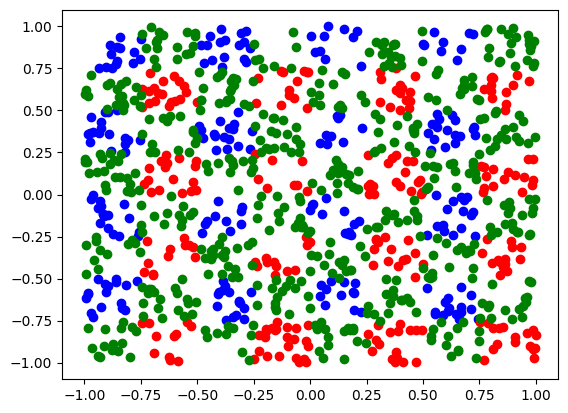

<Figure size 640x480 with 0 Axes>

In [97]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [98]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

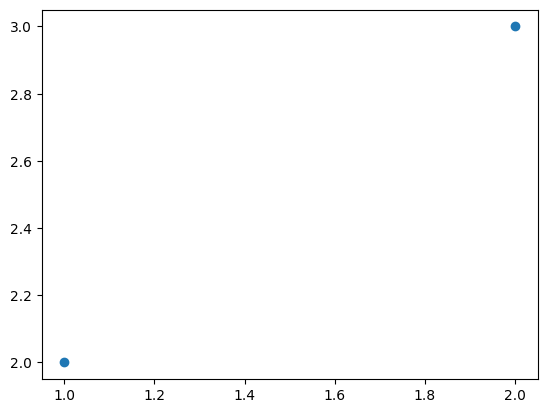

<Figure size 640x480 with 0 Axes>

In [99]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [100]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

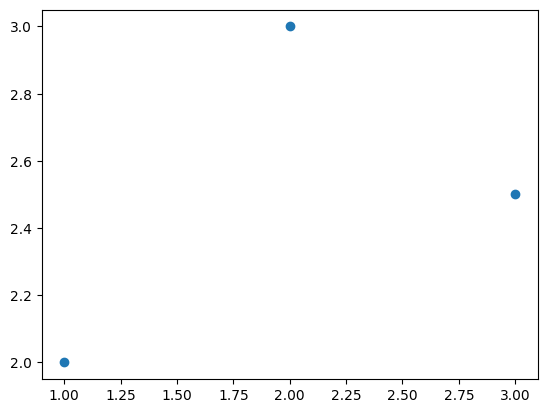

<Figure size 640x480 with 0 Axes>

In [101]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [102]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [103]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [104]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [105]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [106]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [107]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>